In [19]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

ROOT = Path(".")
P4 = "../../images/p4"

def load_image(path):
    return np.asarray(Image.open(path))

def save_image(path, arr):
    arr = np.asarray(arr)
    Image.fromarray(arr.astype(np.uint8)).save(path)

def show_gray(ax, img, title=""):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")

def show_rgb(ax, img, title=""):
    ax.imshow(np.clip(img, 0, 255).astype(np.uint8))
    ax.set_title(title)
    ax.axis("off")

def plot_hist(ax, img_or_h, title="", normalized=False):
    h = hist(img_or_h) if np.asarray(img_or_h).ndim >= 2 else np.asarray(img_or_h)
    if normalized:
        h = h / h.sum()
    ax.plot(np.arange(len(h)), h)
    ax.set_xlim(0, 255)
    ax.set_title(title)
    ax.set_xlabel("Intensity")
    ax.set_ylabel("Probability" if normalized else "Pixel count")
    ax.grid(alpha=0.25)


In [20]:
def hist(img, bins=256):
    return np.bincount(np.asarray(img).ravel(), minlength=bins).astype(np.float64)

def cdf(h):
    h = np.asarray(h, dtype=np.float64)
    total = h.sum()
    if total == 0:
        return np.zeros_like(h)
    return np.cumsum(h) / total

## fix was provided by claude
def rounder(f):
    return np.floor(f+0.5)
### end of fix

def equalise(img):
    img = np.asarray(img, dtype=np.uint8)
    h = hist(img)
    F = cdf(h)
    T = np.clip(rounder(255.0 * F), 0, 255).astype(np.uint8)
    return T[img]

def specify(img, target_hist):
    img = np.asarray(img, dtype=np.uint8)
    h_src = hist(img)
    F_src = cdf(h_src)

    h_tgt = np.asarray(target_hist, dtype=np.float64)
    G = cdf(h_tgt)

    mapping = np.searchsorted(G, F_src, side="left")
    mapping = np.clip(mapping, 0, 255).astype(np.uint8)
    return mapping[img]

def wasserstein1(h1, h2):
    p = np.asarray(h1, dtype=np.float64)
    q = np.asarray(h2, dtype=np.float64)
    p = p / p.sum()
    q = q / q.sum()
    return float(np.sum(np.abs(np.cumsum(p) - np.cumsum(q))))

def bt601_luma(rgb):
    rgb = np.asarray(rgb, dtype=np.float64)
    y = 0.299 * rgb[:,:, 0] + 0.587 * rgb[:,:, 1] + 0.114 * rgb[:,:, 2]
    return np.clip(np.floor(y + 0.5), 0, 255).astype(np.uint8)


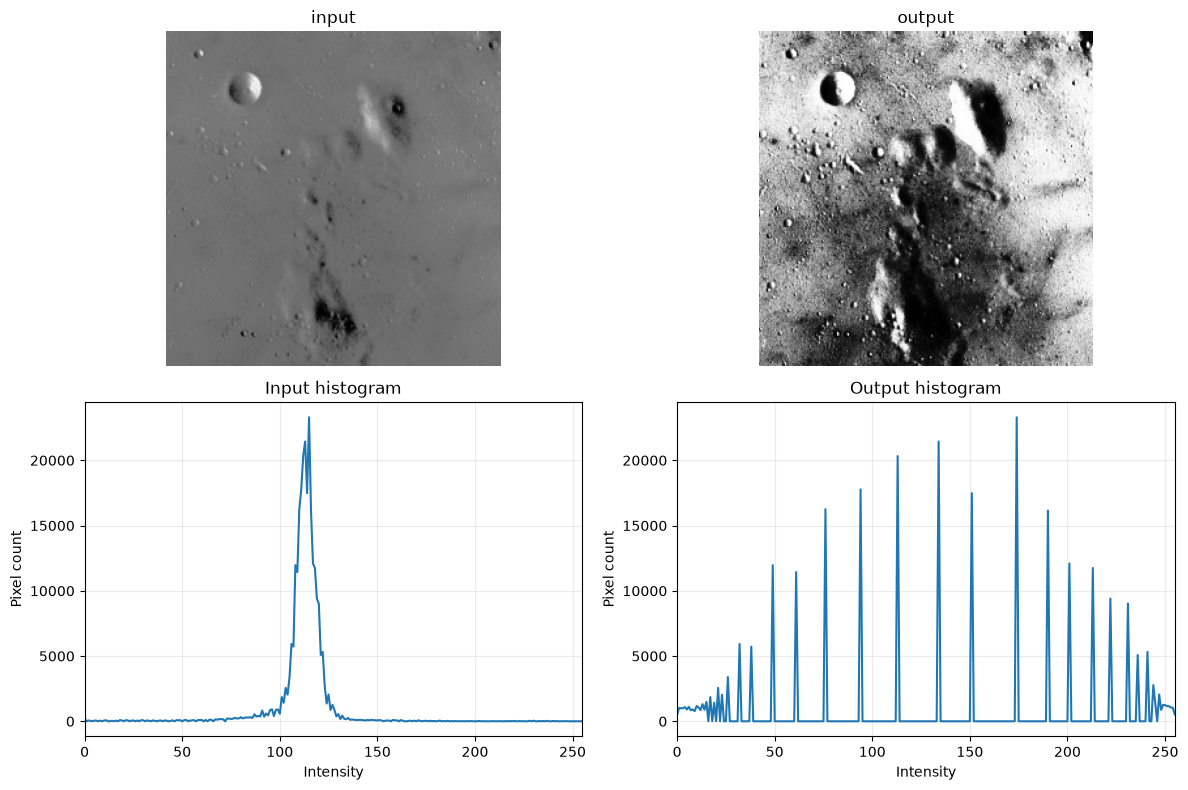

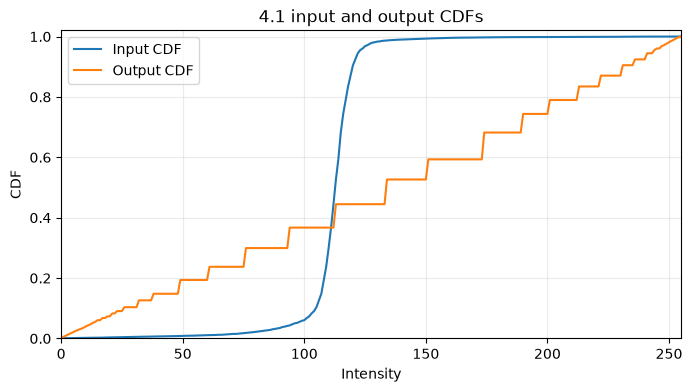

In [21]:
img41 = load_image(P4+"/equalization/input.png")
if img41.ndim == 3:
    img41 = bt601_luma(img41)

out41 = equalise(img41)
h41 = hist(img41)
h41_out = hist(out41)
F41 = cdf(h41)
F41_out = cdf(h41_out)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
show_gray(ax[0,0], img41, "input")
show_gray(ax[0,1], out41, "output")
plot_hist(ax[1,0], h41, "Input histogram")
plot_hist(ax[1,1], h41_out, "Output histogram")
plt.tight_layout()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(256), F41, label="Input CDF")
ax.plot(np.arange(256), F41_out, label="Output CDF")
ax.set_xlabel("Intensity")
ax.set_ylabel("CDF")
ax.set_xlim(0, 255)
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.25)
ax.legend()
ax.set_title("4.1 input and output CDFs")
plt.show()


![Alt text](4.1proof1.jpeg)
![Alt text](4.1proof2.jpeg)


W1 before: 40.774623115463974
W1 after : 0.8604797682221454


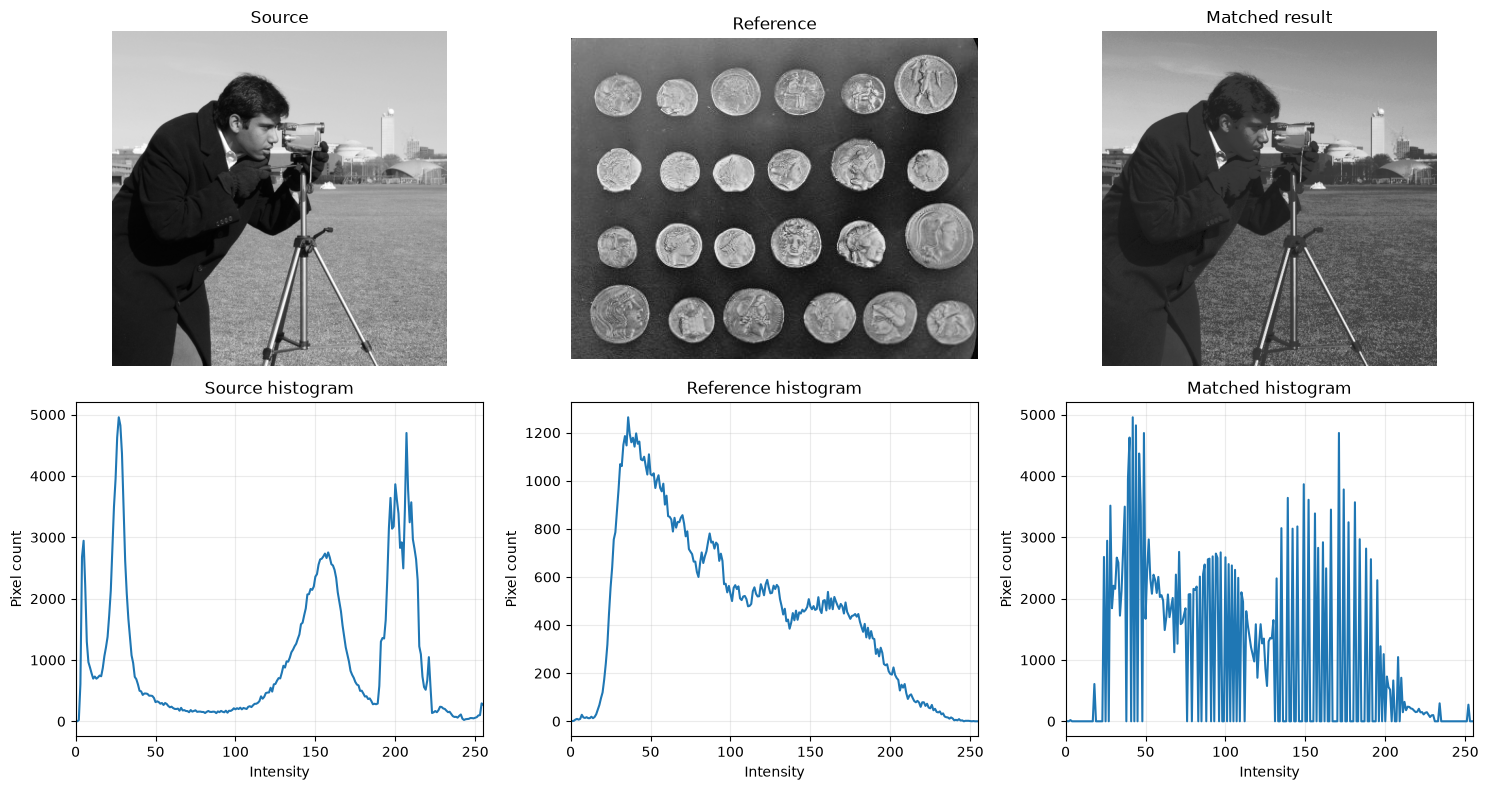

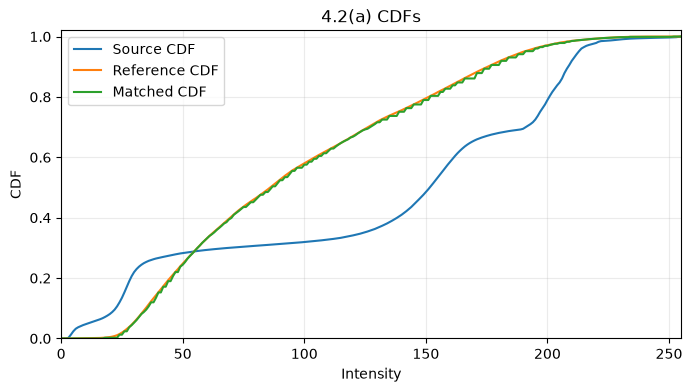

In [22]:
source42a = load_image(P4+"/matching/source.png")
reference42a = load_image(P4+"/matching/reference.png")

h_src = hist(source42a)
h_ref = hist(reference42a)
matched42a = specify(source42a, h_ref)
h_match = hist(matched42a)

print("W1 before:", wasserstein1(h_src, h_ref))
print("W1 after :", wasserstein1(h_match, h_ref))

fig, ax = plt.subplots(2, 3, figsize=(15, 8))
show_gray(ax[0,0], source42a, "Source")
show_gray(ax[0,1], reference42a, "Reference")
show_gray(ax[0,2], matched42a, "Matched result")
plot_hist(ax[1,0], h_src, "Source histogram")
plot_hist(ax[1,1], h_ref, "Reference histogram")
plot_hist(ax[1,2], h_match, "Matched histogram")
plt.tight_layout()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(256), cdf(h_src), label="Source CDF")
ax.plot(np.arange(256), cdf(h_ref), label="Reference CDF")
ax.plot(np.arange(256), cdf(h_match), label="Matched CDF")
ax.set_xlim(0,255); ax.set_ylim(0,1.02)
ax.set_xlabel("Intensity"); ax.set_ylabel("CDF")
ax.grid(alpha=0.25); ax.legend()
ax.set_title("4.2(a) CDFs")
plt.show()


- the Wassertein-1 Distance before = 40.774
- the Wassertein-1 Distance after = 0.860

Uniform
W1 dist before: 69.14639929742378
W1 dist after : 1.6048009367681675
Gaussian
W1 dist before: 67.08518943345088
W1 dist after : 0.7670124275102255


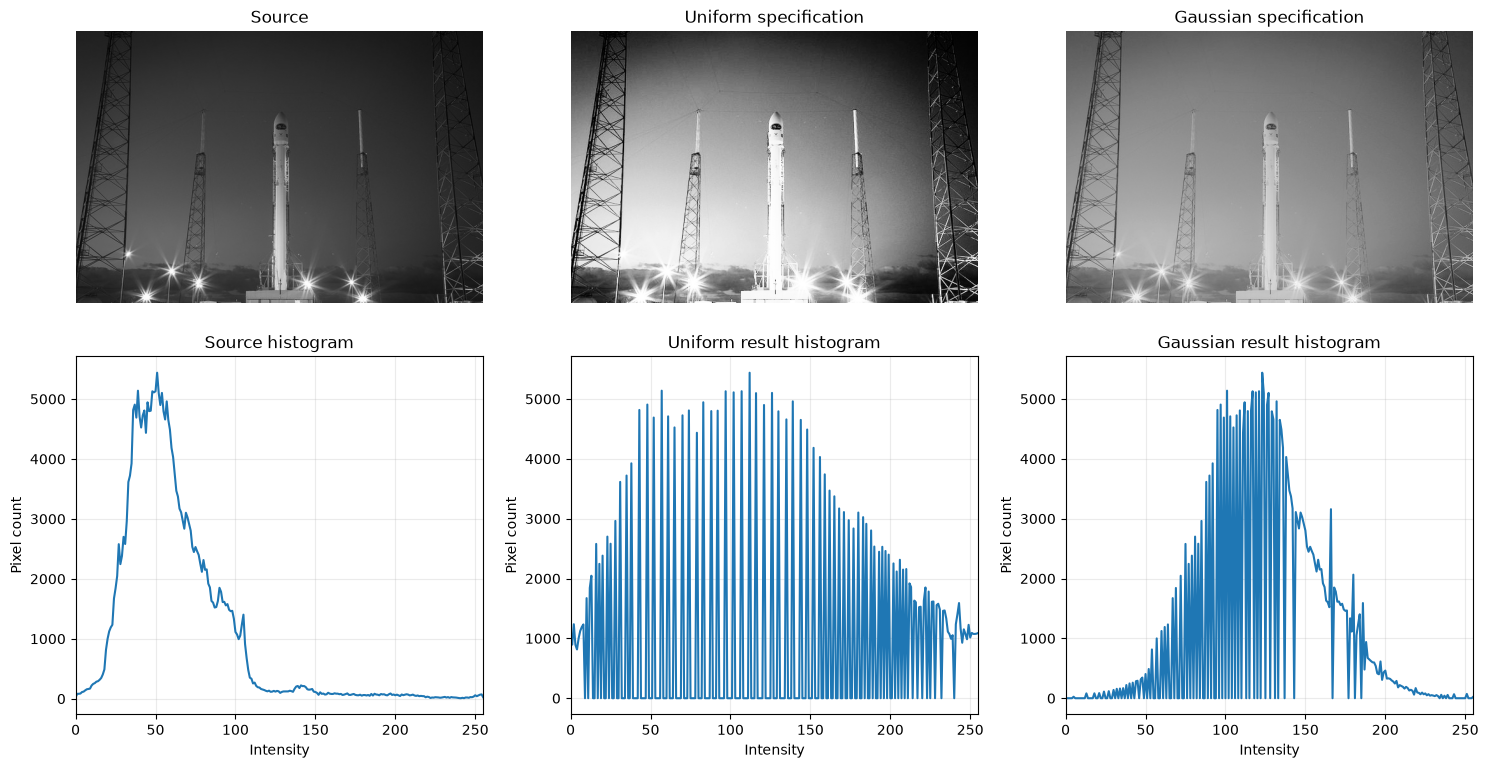

In [23]:
source42b = load_image(P4+"/specification/source.png")
uniform_target = np.ones(256, dtype=np.float64)

x = np.arange(256, dtype=np.float64)
mu, sigma = 128.0, 35.0
gaussian_target = np.exp(-0.5 * ((x - mu) / sigma)**2)

uniform_out = specify(source42b, uniform_target)
gaussian_out = specify(source42b, gaussian_target)

h_source42b = hist(source42b)
h_uniform_out = hist(uniform_out)
h_gaussian_out = hist(gaussian_out)

print("Uniform")
print("W1 dist before:", wasserstein1(h_source42b, uniform_target))
print("W1 dist after :", wasserstein1(h_uniform_out, uniform_target))

print("Gaussian")
print("W1 dist before:", wasserstein1(h_source42b, gaussian_target))
print("W1 dist after :", wasserstein1(h_gaussian_out, gaussian_target))

fig, ax = plt.subplots(2, 3, figsize=(15, 8))
show_gray(ax[0,0], source42b, "Source")
show_gray(ax[0,1], uniform_out, "Uniform specification")
show_gray(ax[0,2], gaussian_out, "Gaussian specification")
plot_hist(ax[1,0], h_source42b, "Source histogram")
plot_hist(ax[1,1], h_uniform_out, "Uniform result histogram")
plot_hist(ax[1,2], h_gaussian_out, "Gaussian result histogram")
plt.tight_layout()


The difference between equalization and specification is that the equalisation has a uniform target whereas specification is a general framework where the target histogram can be chosen arbitrarily like chosing a similar kind of image with better contrast, or like gaussian target. 

uniform specification with ones(256) is essentially plain equalisation both have a uniform target. They might be difference of the +-1 level due to the rounding and searchsorted convention of numpy


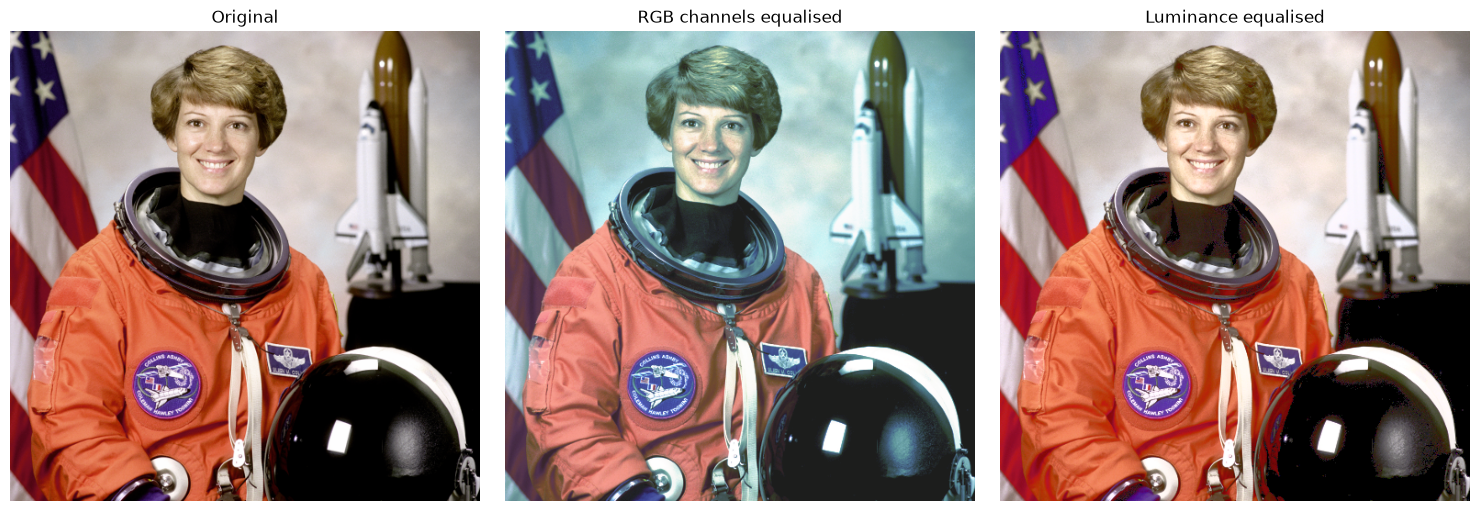

In [24]:
rgb = load_image(P4 + "/colour_source.png").astype(np.uint8)

red_eq   = equalise(rgb[:, :, 0])
green_eq = equalise(rgb[:, :, 1])
blue_eq  = equalise(rgb[:, :, 2])

eq_output = np.stack([red_eq, green_eq, blue_eq], axis=-1)

Y = bt601_luma(rgb)
Y_equalised = equalise(Y).astype(np.float64)
Y_original  = Y.astype(np.float64)

Y_original = np.maximum(Y_original, 1.0)
luminance_scale = Y_equalised / Y_original

rgb_luma_eq = rgb.astype(np.float64) * luminance_scale[:,:, None]
rgb_luma_eq = np.clip(rgb_luma_eq, 0, 255).astype(np.uint8)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
show_rgb(ax[0], rgb, "Original")
show_rgb(ax[1], eq_output, "RGB channels equalised")
show_rgb(ax[2], rgb_luma_eq, "Luminance equalised")

plt.tight_layout()

In [25]:
def rgb_to_hsv01(rgb):
    a = np.asarray(rgb, dtype=np.float64) / 255.0

    r = a[:,:, 0]
    g = a[:,:, 1]
    b = a[:,:, 2]

    mx = np.max(a, axis=-1)
    mn = np.min(a, axis=-1)
    d = mx - mn

    h = np.zeros_like(mx)

    red_max = (mx == r) & (d > 0)
    green_max = (mx == g) & (d > 0) & ~red_max
    blue_max = (mx == b) & (d > 0) & ~red_max & ~green_max

    h[red_max] = ((g[red_max] - b[red_max]) / d[red_max]) % 6
    h[green_max] = ((b[green_max] - r[green_max]) / d[green_max]) + 2
    h[blue_max] = ((r[blue_max] - g[blue_max]) / d[blue_max]) + 4

    h /= 6.0

    s = np.zeros_like(mx)
    valid = mx > 0
    s[valid] = d[valid] / mx[valid]

    return h, s, mx

h0, s0, v0 = rgb_to_hsv01(rgb)
h_rgb, _, _ = rgb_to_hsv01(rgb_eq)
h_lum, _, _ = rgb_to_hsv01(rgb_luma_eq)


def circular_hue_distance_deg(h1, h2):
    difference = np.abs(h1 - h2)
    difference = np.minimum(difference, 1.0 - difference)
    return 360.0 * difference



rgb_hue_shift = circular_hue_distance_deg(h0, h_rgb)
lum_hue_shift = circular_hue_distance_deg(h0, h_lum)
valid_pixels = s0 > 0.05


mean_rgb_shift = rgb_hue_shift[valid_pixels].mean()
mean_lum_shift = lum_hue_shift[valid_pixels].mean()

print("Mean hue shift, independent RGB equalisation (degrees):",
      mean_rgb_shift)
print("Mean hue shift, luminance-only equalisation (degrees):",
      mean_lum_shift)


Mean hue shift, independent RGB equalisation (degrees): 81.60439457077395
Mean hue shift, luminance-only equalisation (degrees): 0.6825719706124755


- the color space for hue measurement is hsv
- the circular hue distance formula is defined as f(h1,h2) = 360* min(|h1-h2|, 1-|h1-h2|)
- we exclude the near achromatic pixels with a threshold of 0.05
- per channel result is wrong because histogram equalisation assumes the input values represent samples of one intensity variable whose distribution is being remapped. The R, G, B are not independent representation of the intensity of the image but rather are connected hence when equalized independently there is a huge loss in the original colors. This can be seen from the mean hue shift of ~81degrees for the independent RGB equalization and a mean hue shift of ~0.682 degrees for the luminance equalization. 



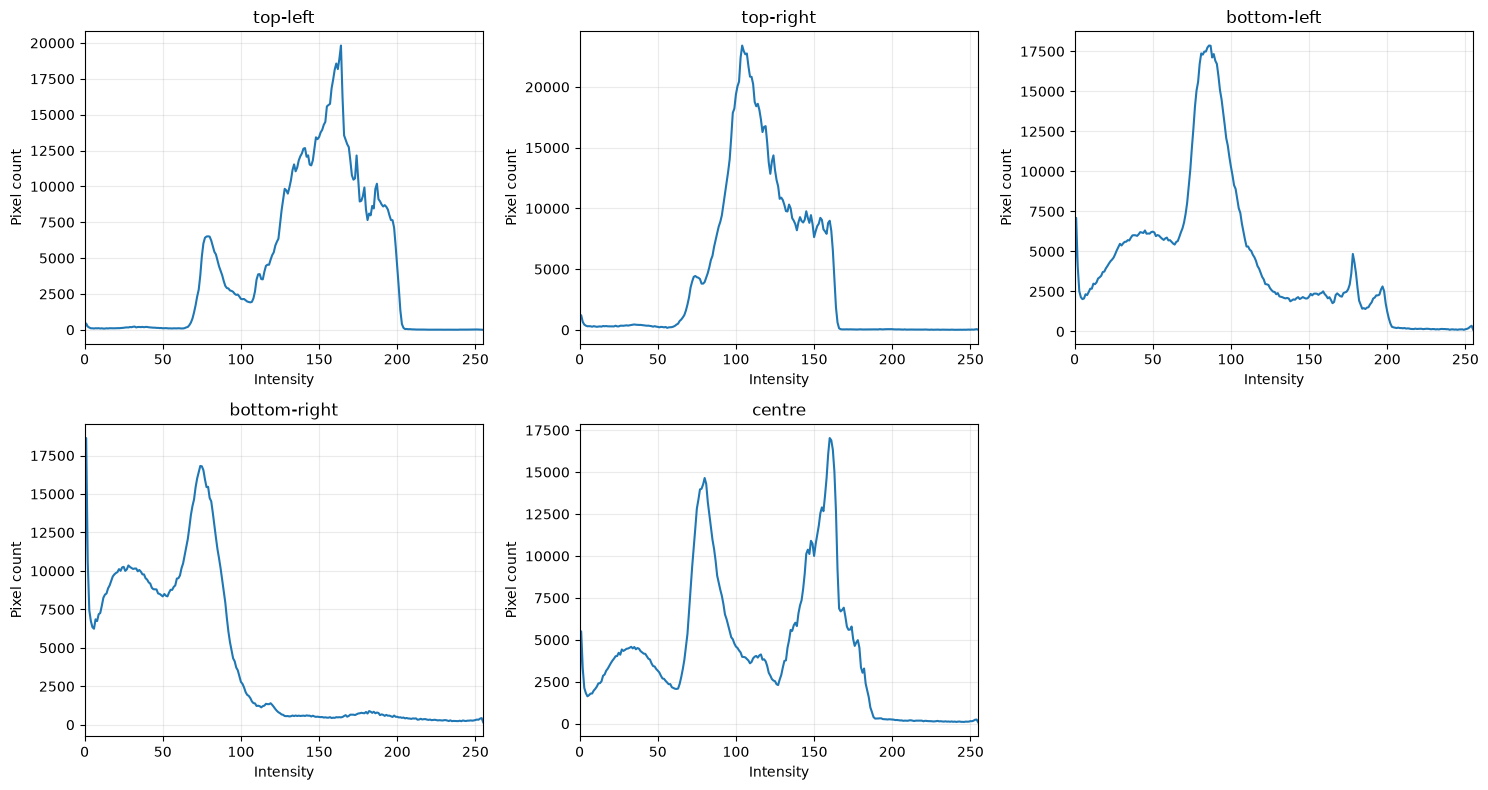

In [27]:
local_rgb = load_image(P4+"/local_regions.png")
local_y = bt601_luma(local_rgb) if local_rgb.ndim == 3 else local_rgb.astype(np.uint8)

H, W = local_y.shape

patch_boxes = [
    ("top-left", 0, H//2, 0, W//2),
    ("top-right", 0, H//2, W//2, W),
    ("bottom-left", H//2, H, 0, W//2),
    ("bottom-right", H//2, H, W//2, W),
    ("centre", H//4, 3*H//4, W//4, 3*W//4),
]

fig, ax = plt.subplots(2, 3, figsize=(15, 8))
for k, (name, y0, y1, x0, x1) in enumerate(patch_boxes):
    r, c = divmod(k, 3)
    patch = local_y[y0:y1, x0:x1]
    plot_hist(ax[r,c], patch, name)
ax[1,2].axis("off")
plt.tight_layout()


Different patches have different local illumination and contrast. like the top left has very few ~0 pixel count for intensities upto around 60-70 but regions like the bottom right have good pixel representation for the same. The peak (maximum pixel count) for the top part (top right and top left) occur after intensity 100 whereas the local illumination is dimmer/darker in the lower half as the peaks occur at intensities less than a 100. 
It is because of these differences it is not possible to find a single global mapping for all of these different patches. 


In [32]:
def tile_bounds(length, tiles):
    edges = np.linspace(0, length, tiles + 1).round().astype(int)
    edges[0] = 0
    edges[-1] = length
    return edges

def local_lut_from_hist(h, clip=None):
    h = np.asarray(h, dtype=np.float64).copy()
    if clip is not None:
        limit = float(clip)
        excess = np.maximum(h - limit, 0.0)
        h = np.minimum(h, limit)
        total_excess = excess.sum()
        if total_excess > 0:
            add = total_excess // len(h)
            rem = int(total_excess - add * len(h))
            h += add
            if rem > 0:
                h[:rem] += 1
    F = cdf(h)
    return np.clip(rounder(255 * F), 0, 255).astype(np.uint8)

def ahe(img, tiles=8):
    img = np.asarray(img, dtype=np.uint8)
    H, W = img.shape
    ys = tile_bounds(H, tiles)
    xs = tile_bounds(W, tiles)
    out = np.empty_like(img)

    for ty in range(tiles):
        for tx in range(tiles):
            y0, y1 = ys[ty], ys[ty+1]
            x0, x1 = xs[tx], xs[tx+1]
            tile = img[y0:y1, x0:x1]
            lut = local_lut_from_hist(hist(tile))
            out[y0:y1, x0:x1] = lut[tile]
    return out


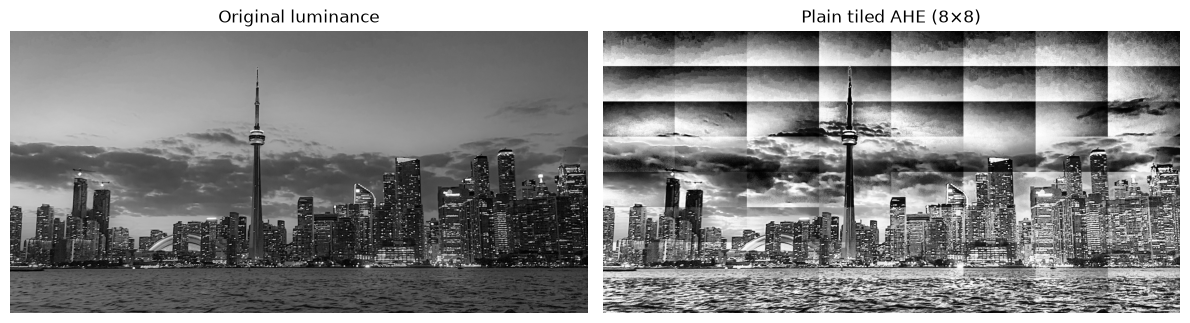

In [33]:
ahe8 = ahe(local_y, tiles=8)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
show_gray(ax[0], local_y, "Original luminance")
show_gray(ax[1], ahe8, "Plain tiled AHE (8×8)")
plt.tight_layout()


- Noise amplification: In a small tile which is nearly uniform a tiny histogram fluctuation or noise doesnt change the global histogram by a lot but occupies a large fraction of the local CDF. As it is well represented in the local CDF upon independent local histogram equalization it gets amplified.
- As visible from the image as well there seem to be discontinuities between tiles in the final result. This is because we are computing the local histogram equalization independently so for adjacent tiles a small change in position changes the LUT used for CF inversion which can change the output levels hence leading to tile discontinuities.


In [34]:
def _clahe_luts(img, tiles, clip, bins=256):
    H, W = img.shape
    ys = tile_bounds(H, tiles)
    xs = tile_bounds(W, tiles)
    luts = np.empty((tiles, tiles, bins), dtype=np.uint8)

    for ty in range(tiles):
        for tx in range(tiles):
            tile = img[ys[ty]:ys[ty+1], xs[tx]:xs[tx+1]]
            mean_bin_height = tile.size / float(bins)
            if np.isinf(clip):
                lut = local_lut_from_hist(hist(tile), clip=None)
            else:
                lut = local_lut_from_hist(hist(tile), clip=clip * mean_bin_height)
            luts[ty, tx] = lut
    return luts, ys, xs

def clahe(img, tiles=8, clip=3.0, bins=256):
    img = np.asarray(img, dtype=np.uint8)
    H, W = img.shape
    luts, ys, xs = _clahe_luts(img, tiles, clip, bins)

    cy = (ys[:-1] + ys[1:] - 1) / 2.0
    cx = (xs[:-1] + xs[1:] - 1) / 2.0

    yy, xx = np.indices((H, W), dtype=np.float64)

    iy1 = np.searchsorted(cy, yy, side="right")
    iy1 = np.clip(iy1, 1, tiles - 1)
    iy0 = iy1 - 1
    wy = (yy - cy[iy0]) / np.maximum(cy[iy1] - cy[iy0], 1e-12)
    wy = np.clip(wy, 0, 1)

    ix1 = np.searchsorted(cx, xx, side="right")
    ix1 = np.clip(ix1, 1, tiles - 1)
    ix0 = ix1 - 1
    wx = (xx - cx[ix0]) / np.maximum(cx[ix1] - cx[ix0], 1e-12)
    wx = np.clip(wx, 0, 1)

    v = img
    a = luts[iy0, ix0, v].astype(np.float64)
    b = luts[iy0, ix1, v].astype(np.float64)
    c = luts[iy1, ix0, v].astype(np.float64)
    d = luts[iy1, ix1, v].astype(np.float64)

    out = (1-wy)*(1-wx)*a + (1-wy)*wx*b + wy*(1-wx)*c + wy*wx*d
    return np.clip(np.floor(out + 0.5), 0, 255).astype(np.uint8)

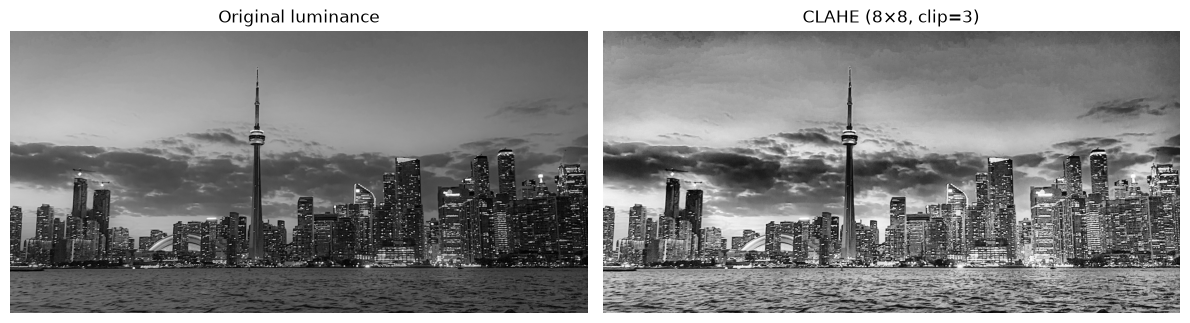

In [35]:
# 4.3(c) CLAHE
clahe8 = clahe(local_y, tiles=8, clip=3.0)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
show_gray(ax[0], local_y, "Original luminance")
show_gray(ax[1], clahe8, "CLAHE (8×8, clip=3)")
plt.tight_layout()


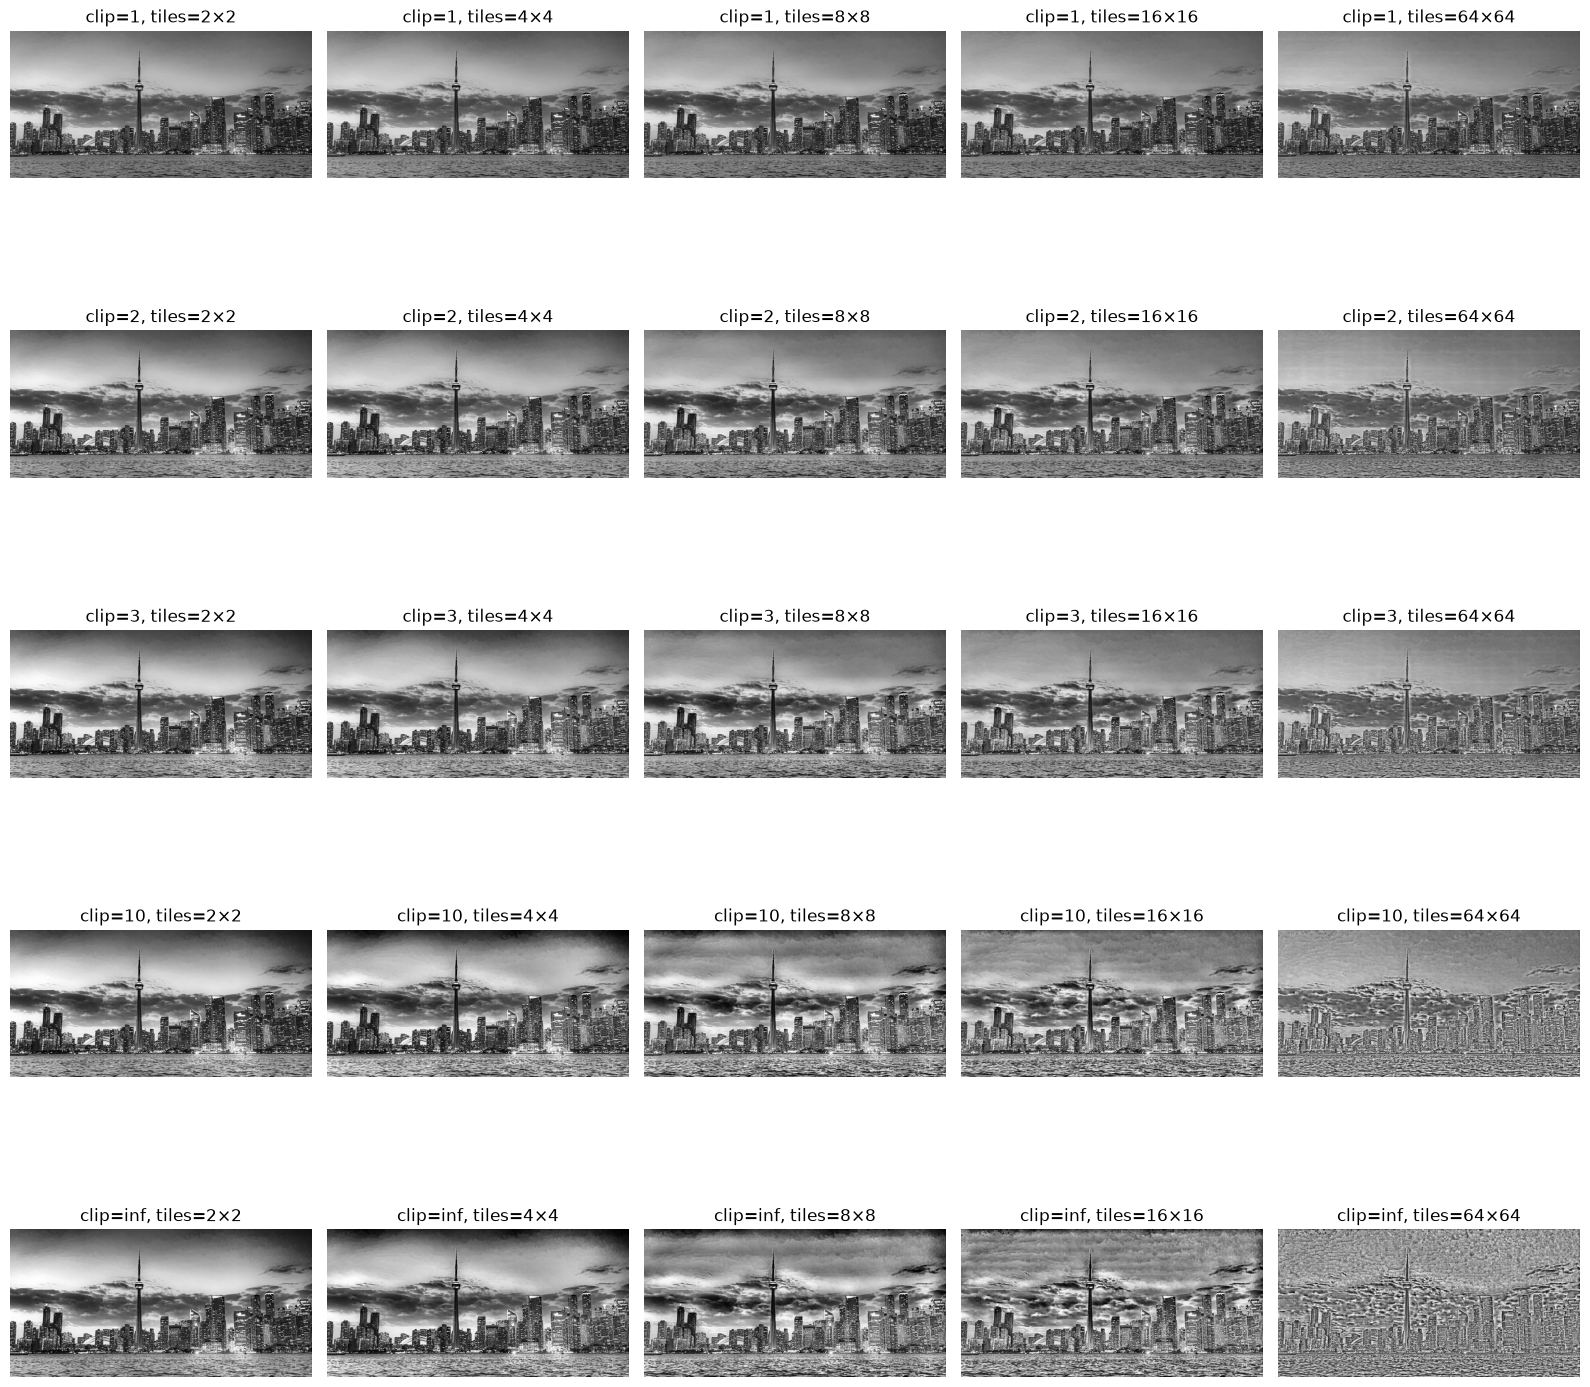

In [21]:
clip_values = [1, 2, 3, 10, np.inf]
tile_values = [2, 4, 8, 16, 64]

fig, ax = plt.subplots(len(clip_values), len(tile_values), figsize=(16, 16))
for r, clipv in enumerate(clip_values):
    for c, tv in enumerate(tile_values):
        out = clahe(local_y, tiles=tv, clip=clipv)
        ax[r,c].imshow(out, cmap="gray", vmin=0, vmax=255)
        ax[r,c].set_title(f"clip={clipv}, tiles={tv}×{tv}")
        ax[r,c].axis("off")
plt.tight_layout()


- Boundary 1 (Clip limit 1): As the clipping is very agressive , each bin = mean bin height because of which there is almost no local contrast enhancement. 
- Boundary 2 (Climp limit inf): At clip limit inf CLAHE becomes practically AHE so we see noise amplification in plain/ low contrast tiles.
- Boundary 3 (Tile count 2): As the tiles are very big it has the same issues as global histogram equalization where there are different local illumination and contrast within the tile which one singular global mapping cant capture. 
- Boundary 4 (Tile count 64): As the tiles are very small the local adpatation becomes aggressive and unstable. Minor changes spatially can lead to pixels having very different LUT (as they belong to different tiles) which can lead to very different output levels within spatial neighbours.

Patch-wise W1 to the supplied target histogram
Patch             CLAHE       Local specification
top-left          37.9400               3.0660
top-right         22.8558               3.6002
bottom-left       18.6923               1.2254
bottom-right      14.0666               1.1636
centre            25.8356               2.1605


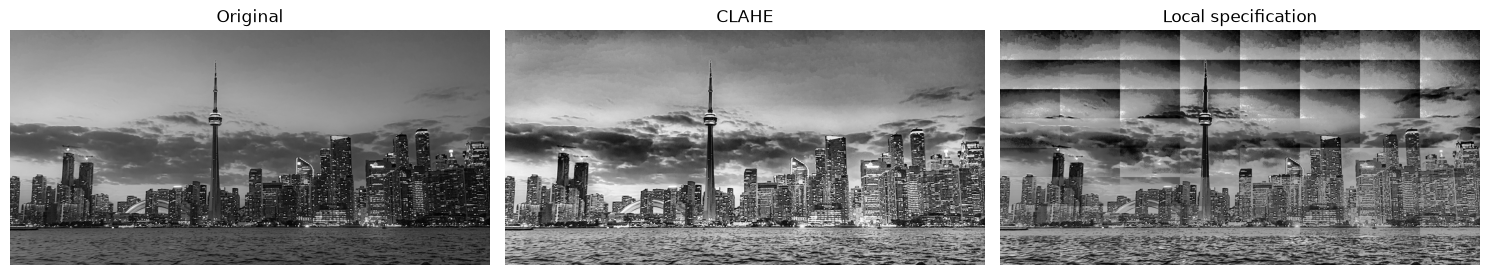

In [ ]:
def local_specify(img, target_hist, tiles=8):
    img = np.asarray(img, dtype=np.uint8)
    H, W = img.shape
    ys = tile_bounds(H, tiles)
    xs = tile_bounds(W, tiles)
    out = np.empty_like(img)

    for ty in range(tiles):
        for tx in range(tiles):
            y0, y1 = ys[ty], ys[ty+1]
            x0, x1 = xs[tx], xs[tx+1]
            tile = img[y0:y1, x0:x1]
            out[y0:y1, x0:x1] = specify(tile, target_hist)
    return out

_, y0, y1, x0, x1 = patch_boxes[4]
reference_patch = local_y[y0:y1, x0:x1]
target_h = hist(reference_patch)

local_spec8 = local_specify(local_y, target_h, tiles=8)
clahe8_for_compare = clahe(local_y, tiles=8, clip=3.0)

print("Wassertein-1 distance to supplied target histogram")
print("Patch             CLAHE       Local specification")
for name, y0, y1, x0, x1 in patch_boxes:
    p_clahe = clahe8_for_compare[y0:y1, x0:x1]
    p_spec = local_spec8[y0:y1, x0:x1]
    w_clahe = wasserstein1(hist(p_clahe), target_h)
    w_spec = wasserstein1(hist(p_spec), target_h)
    print(f"{name:14s} {w_clahe:10.4f} {w_spec:20.4f}")

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
show_gray(ax[0], local_y, "Original")
show_gray(ax[1], clahe8_for_compare, "CLAHE")
show_gray(ax[2], local_spec8, "Local specification")
plt.tight_layout()


Local histogram specification achieved substantially better matching to the supplied target histogram than CLAHE, as shown by the lower Wasserstein-1 distances. However, the independent tile-wise mappings introduced visible boundaries and amplified local noise

The extra information which we suplied was the target histogram from a reference image patch.

But as this tile-wise specification is independent we see issues similar to the independent local histogram equalization (AHE) such as visible tile boundaries, amplified noise etc. 

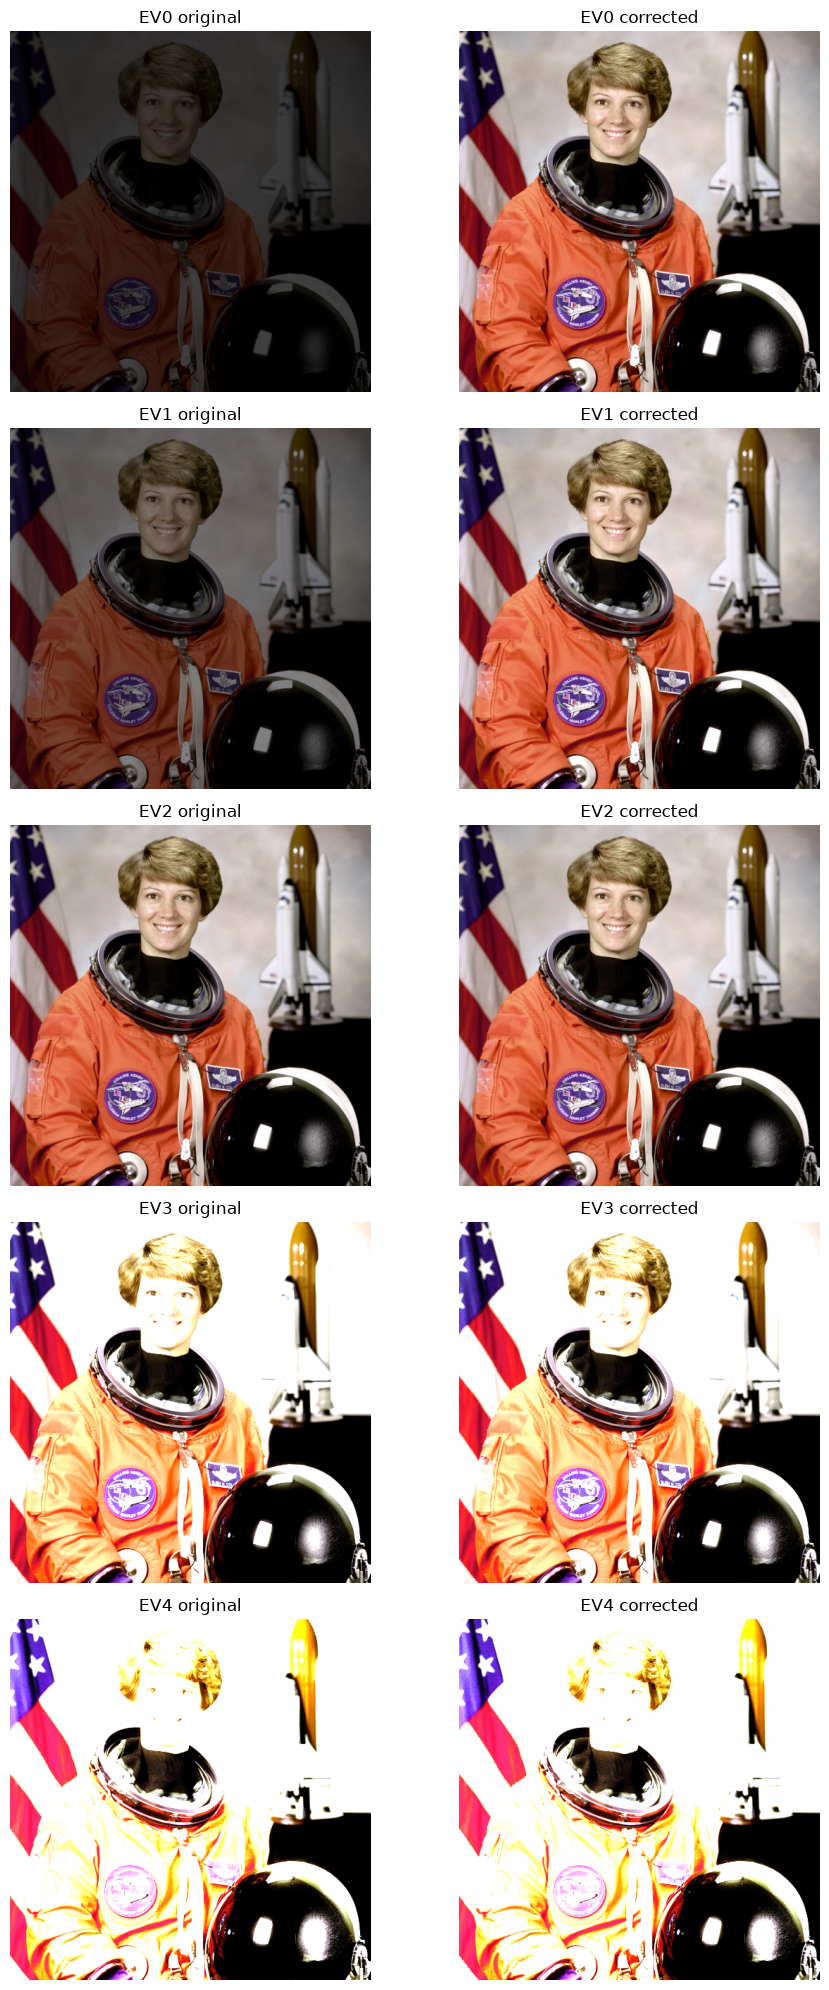

In [36]:
def auto_correct(rgb):
    rgb = np.asarray(rgb, dtype=np.uint8)
    if rgb.ndim == 2:
        y = rgb.astype(np.float64)
        lo, hi = np.percentile(y, [1, 99])
        if hi <= lo + 1e-9:
            return rgb.copy()
        out = (y - lo) * (253.0 / (hi - lo)) + 1.0
        return np.clip(np.floor(out + 0.5), 0, 255).astype(np.uint8)

    y = bt601_luma(rgb).astype(np.float64)
    lo, hi = np.percentile(y, [1, 99])
    if hi <= lo + 1e-9:
        return rgb.copy()

    scale = ((y - lo) * (253.0 / (hi - lo)) + 1.0)
    scale = scale / np.maximum(y, 1.0)

    out = np.clip(rgb.astype(np.float64) * scale[:,:, None], 0, 255)
    return np.floor(out + 0.5).astype(np.uint8)

def exposure_paths():
    return [P4+"/exposure"+f"/ev{i}.png" for i in range(5)]

exposures = [load_image(p) for p in exposure_paths()]
corrected = [auto_correct(im) for im in exposures]

fig, ax = plt.subplots(5, 2, figsize=(10, 20))
for i, (im, out) in enumerate(zip(exposures, corrected)):
    show_rgb(ax[i,0], im, f"EV{i} original")
    show_rgb(ax[i,1], out, f"EV{i} corrected")
plt.tight_layout()


In [37]:
def luminance_hist(rgb):
    return hist(bt601_luma(rgb))

def pairwise_w1_stats(images):
    hs = [luminance_hist(im) for im in images]
    vals = []
    pairs = []
    for i in range(len(hs)):
        for j in range(i+1, len(hs)):
            d = wasserstein1(hs[i], hs[j])
            vals.append(d)
            pairs.append((i, j, d))
    vals = np.asarray(vals)
    return vals, pairs

before_vals, before_pairs = pairwise_w1_stats(exposures)
after_vals, after_pairs = pairwise_w1_stats(corrected)

# for i, j, d in before_pairs:
#     print(f"EV{i} vs EV{j}: {d:.6f}")

# for i, j, d in after_pairs:
#     print(f"EV{i} vs EV{j}: {d:.6f}")

print("\nMean W1 before:", float(before_vals.mean()))
print("Max  W1 before:", float(before_vals.max()))
print("Mean W1 after :", float(after_vals.mean()))
print("Max  W1 after :", float(after_vals.max()))

print("\nOutput luma statistics")
for i, out in enumerate(corrected):
    y = bt601_luma(out).astype(np.float64)
    p1, p99 = np.percentile(y, [1, 99])
    print(f"EV{i}: std={y.std():.4f}, 1st–99th={p1:.2f}–{p99:.2f}")



Mean W1 before: 88.94670944213867
Max  W1 before: 165.3108367919922
Mean W1 after : 41.2219741821289
Max  W1 after : 76.43537139892578

Output luma statistics
EV0: std=76.4375, 1st–99th=0.00–252.00
EV1: std=76.7198, 1st–99th=0.00–253.00
EV2: std=76.7340, 1st–99th=0.00–253.00
EV3: std=96.5785, 1st–99th=0.00–254.00
EV4: std=94.9793, 1st–99th=0.00–254.00


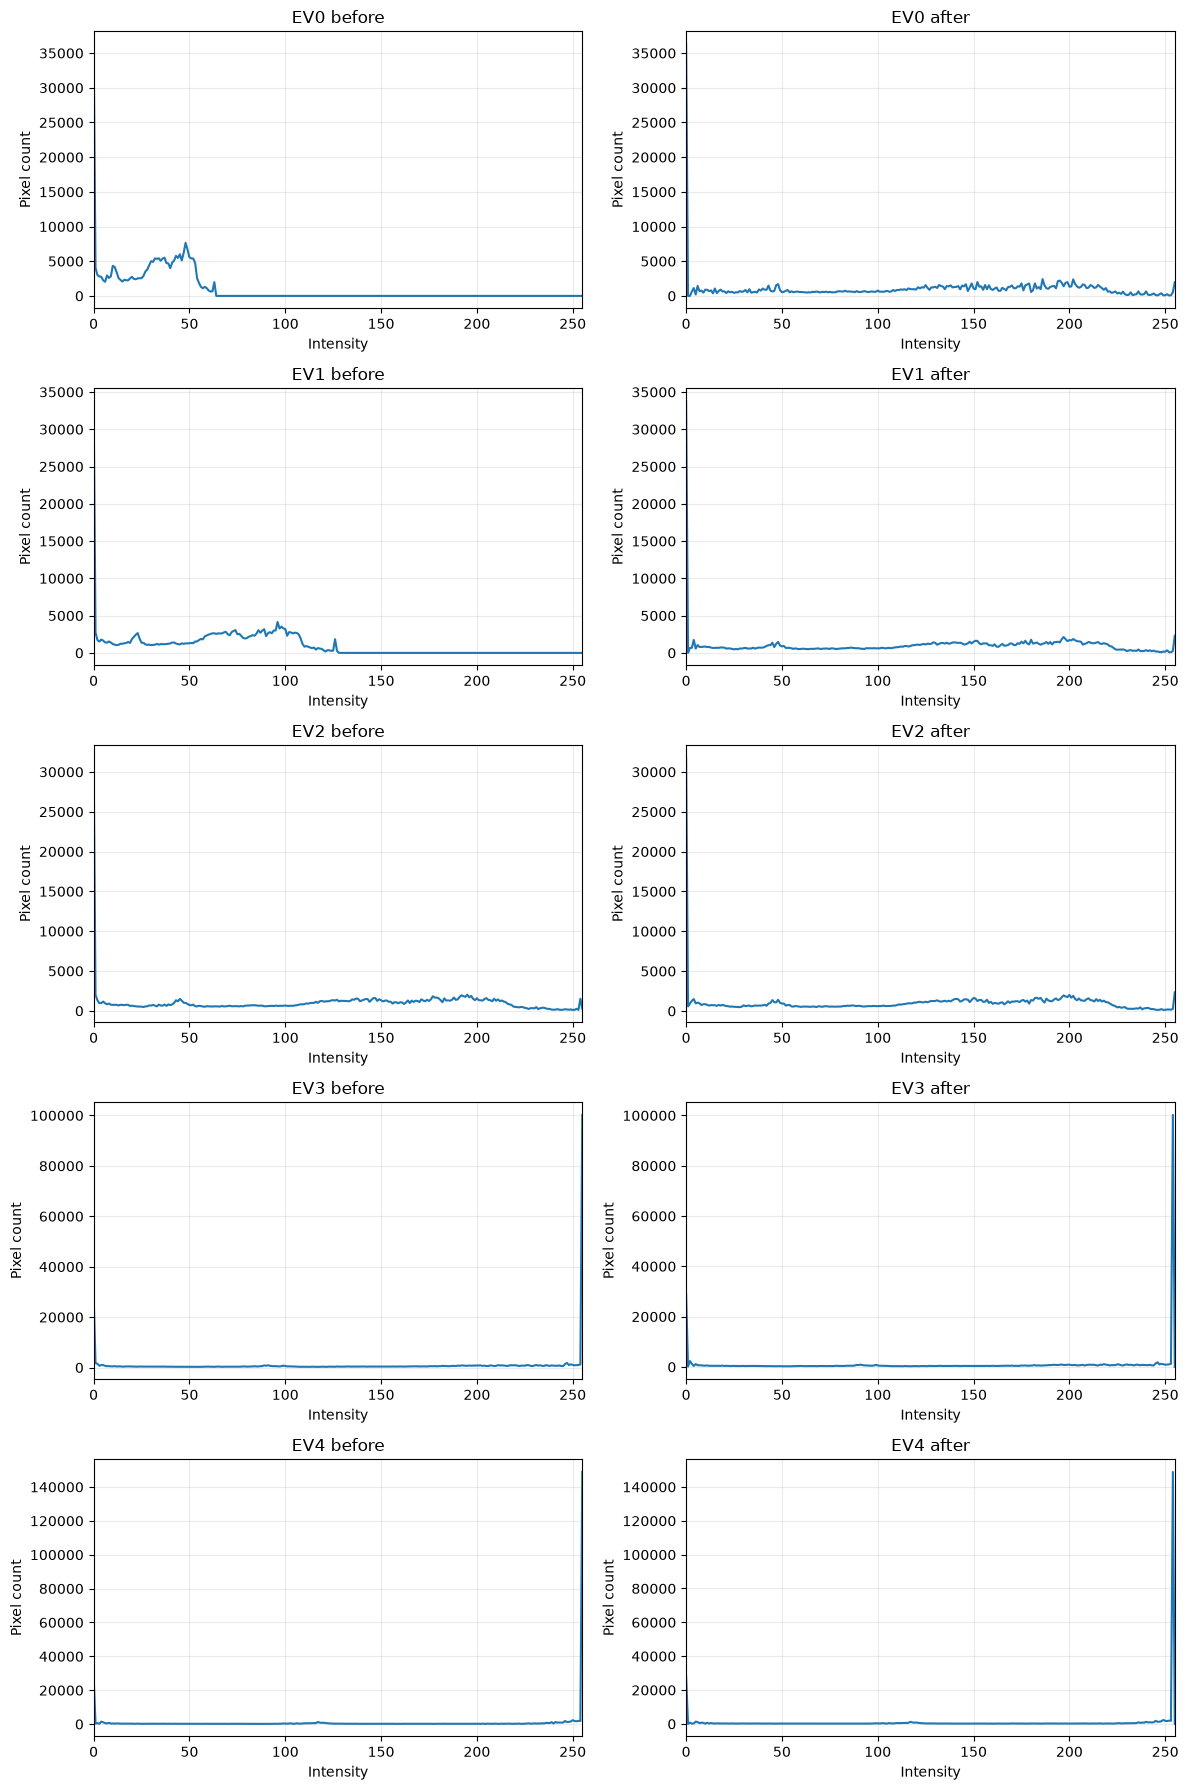

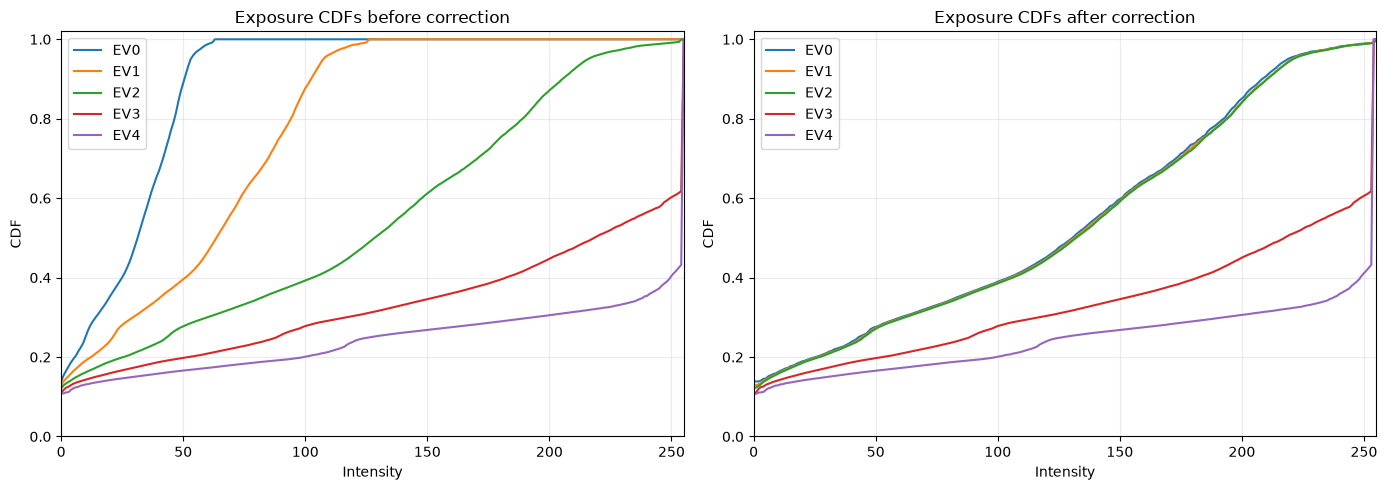

In [38]:
fig, ax = plt.subplots(5, 2, figsize=(12, 18))
for i, (im, out) in enumerate(zip(exposures, corrected)):
    y0 = bt601_luma(im)
    y1 = bt601_luma(out)
    plot_hist(ax[i,0], y0, f"EV{i} before")
    plot_hist(ax[i,1], y1, f"EV{i} after")
plt.tight_layout()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for i, (im, out) in enumerate(zip(exposures, corrected)):
    ax[0].plot(np.arange(256), cdf(hist(bt601_luma(im))), label=f"EV{i}")
    ax[1].plot(np.arange(256), cdf(hist(bt601_luma(out))), label=f"EV{i}")
for a, title in zip(ax, ["Exposure CDFs before correction", "Exposure CDFs after correction"]):
    a.set_xlim(0,255); a.set_ylim(0,1.02)
    a.set_xlabel("Intensity"); a.set_ylabel("CDF")
    a.set_title(title); a.grid(alpha=0.25); a.legend()
plt.tight_layout()


- the 1st and 99th percentile of teahc of the images luminance are estimated and the image is scaled so those exposure anchors map to a common range. 
- this percentile based normalisation can failt when the 1st and 99th percentile anchors are not representative of the scenes total exposure as can be seen from the EV3 and EV4 corrected images (which were too bright (even a contrasting case where both the 1st and 99th are too dark will also break)). It can also clip legitmate light vs shadow effects of the image when this difference is not well represented in the global scale. 
